<a href="https://colab.research.google.com/github/adisberhe/pytorch-models-lab/blob/main/6_classes_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


NUM_CLASS = 6
NUM_FEATURES = 2
n_samples = 1000
device = 'cuda' if torch.cuda.is_available() else 'cpu'


  separate data into test and train datasets

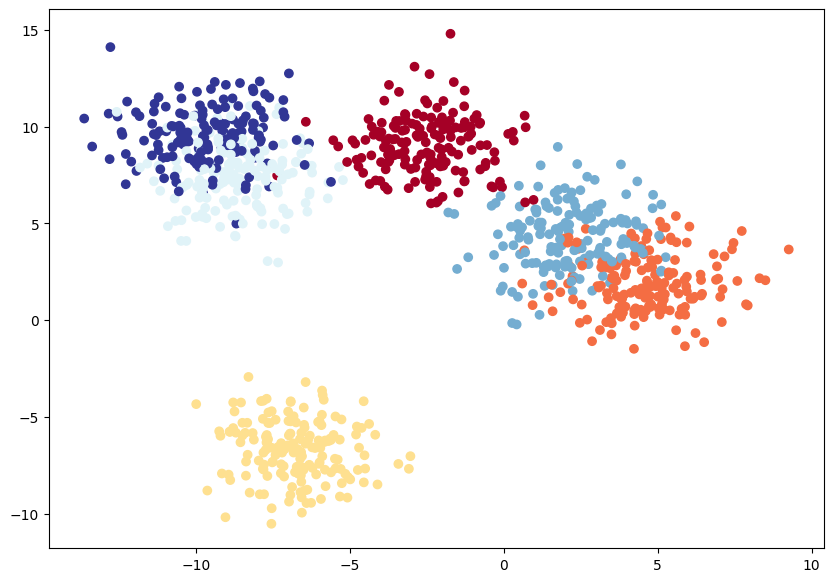

In [40]:
X_blob, y_blob = make_blobs(n_samples,
                            n_features = NUM_FEATURES,
                            centers = NUM_CLASS,
                            cluster_std = 1.5,
                            random_state = 42
                            )
X_blobs = torch.from_numpy(X_blob).type(torch.float)
y_blobs = torch.from_numpy(y_blob).type(torch.LongTensor)

X_train,X_test,y_train, y_test = train_test_split(X_blobs,
                                  y_blobs,
                                  test_size = 0.2,
                                  random_state = 42
                                  )

X_train,X_test,y_train, y_test  = X_train.to(device),X_test.to(device),y_train.to(device),y_test.to(device)

plt.figure(figsize = (10,7))
plt.scatter(X_blobs[:,0],
            X_blobs[:,1],
            c = y_blobs,
            cmap = plt.cm.RdYlBu)
plt.show()

In [41]:

class BlobModel(nn.Module):
    def __init__(self,input_features, output_features,hidden_units):
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features = input_features, out_features = hidden_units),
            nn.ReLU(),
            nn.Linear(in_features = hidden_units, out_features = hidden_units),
            nn.ReLU(),
            nn.Linear(in_features = hidden_units, out_features = output_features),
            nn.ReLU()
        )

    def forward(self,x):
        return self.linear_layer_stack(x)


model_0 = BlobModel(2,NUM_CLASS,8).to(device)


In [42]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                           lr = 0.1)
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test)
    y_preds = torch.softmax(y_logits, dim=1)
    y_preds = torch.argmax(y_preds, dim=1)

y_test[:10], y_preds[:10]

(tensor([1, 1, 2, 3, 0, 4, 5, 1, 2, 1], device='cuda:0'),
 tensor([3, 3, 1, 0, 3, 3, 0, 5, 1, 5], device='cuda:0'))

In [43]:
epochs = 1000

for epoch in range(epochs):

  model_0.train()

  y_logits = model_0(X_train)
  y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)
  #y_preds = torch.argmax(y_preds, dim=1)

  loss = loss_fn(y_logits, y_train)
  optimizer.zero_grad()


  loss.backward()
  optimizer.step()
  acc = accuracy_fn(y_train,y_preds)


  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test)
    test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_preds)

    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 1.8671 | Acc: 9.62% | Test Loss: 1.67229 | Test Acc: 23.00%
Epoch: 100 | Loss: 1.0111 | Acc: 49.12% | Test Loss: 0.94429 | Test Acc: 52.50%
Epoch: 200 | Loss: 0.9630 | Acc: 51.88% | Test Loss: 0.90429 | Test Acc: 54.00%
Epoch: 300 | Loss: 0.9460 | Acc: 52.88% | Test Loss: 0.88856 | Test Acc: 56.00%
Epoch: 400 | Loss: 0.9356 | Acc: 53.12% | Test Loss: 0.87843 | Test Acc: 57.00%
Epoch: 500 | Loss: 0.9284 | Acc: 53.00% | Test Loss: 0.86982 | Test Acc: 59.00%
Epoch: 600 | Loss: 0.9230 | Acc: 53.50% | Test Loss: 0.86338 | Test Acc: 60.00%
Epoch: 700 | Loss: 0.9186 | Acc: 53.87% | Test Loss: 0.85848 | Test Acc: 59.50%
Epoch: 800 | Loss: 0.9149 | Acc: 53.87% | Test Loss: 0.85496 | Test Acc: 59.50%
Epoch: 900 | Loss: 0.9114 | Acc: 53.87% | Test Loss: 0.85125 | Test Acc: 60.00%


In [44]:
import requests
from pathlib import Path

if Path('helper_functions.py').is_file():
  print('Helper functions already downloaded')
else:
  print('Downloading helper functions...')
  request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
  with open('helper_functions.py','wb') as f:
    f.write(request.content)

from helper_functions import plot_predictions,plot_decision_boundary

Helper functions already downloaded


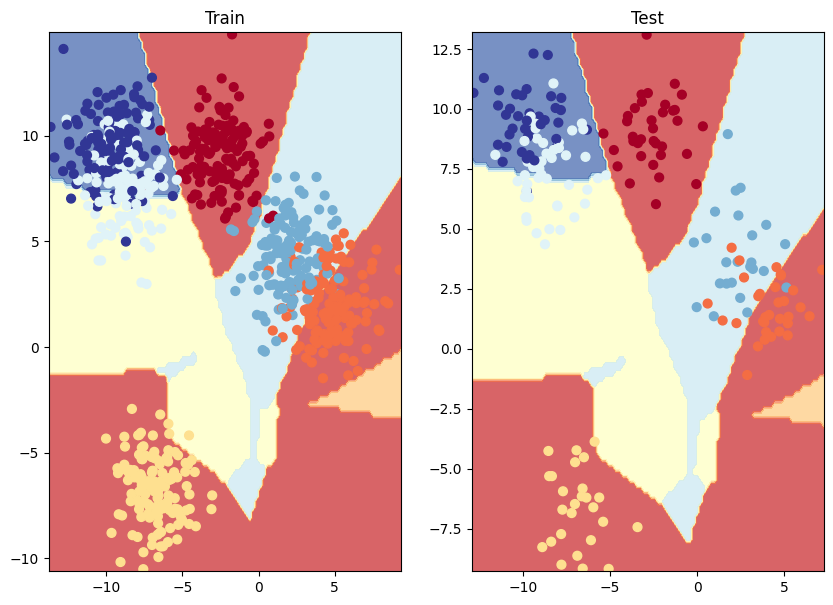

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=6, bias=True)
    (5): ReLU()
  )
)

In [45]:
plt.figure(figsize = (10,7))
plt.subplot(1,2,1)
plt.title('Train')
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title('Test')
plot_decision_boundary(model_0, X_test, y_test)
plt.show()
model_0.to(device)


In [46]:
!pip install torchmetrics

In [47]:
from torchmetrics import Accuracy
acc = Accuracy(task="multiclass", num_classes=NUM_CLASS).to(device)
acc(y_preds,y_train)

tensor(0.5587, device='cuda:0')